In [1]:
import qiskit
from qiskit import *
import numpy as np
from qiskit import QuantumRegister, QuantumCircuit, transpile
from qiskit.quantum_info import Statevector    
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Session 
from qiskit.quantum_info import state_fidelity
import qiskit.quantum_info as qi
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
from qiskit.providers.fake_provider import *
from qiskit.providers import *
from qiskit_aer import AerSimulator
import qiskit_aer.noise as noise

In [2]:
"""QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="TOKEN",
    overwrite=True
)

service = QiskitRuntimeService()
backend = service.backend("ibm_torino")"""

'QiskitRuntimeService.save_account(\n    channel="ibm_quantum_platform",\n    token="TOKEN",\n    overwrite=True\n)\n\nservice = QiskitRuntimeService()\nbackend = service.backend("ibm_torino")'

In [3]:
m = 3 #qubit di indirizzo + 1 ancilla

n = ((2*(m-1))+ (2*(2**(m-1)))) #qubit di memoria (il doppio perché siamo in dual rail encoding)


bus = QuantumRegister(1, name='bus')
addr = QuantumRegister(m, name='addr')
qram = QuantumRegister(n, name='qram')
qc = QuantumCircuit(bus,addr,qram)

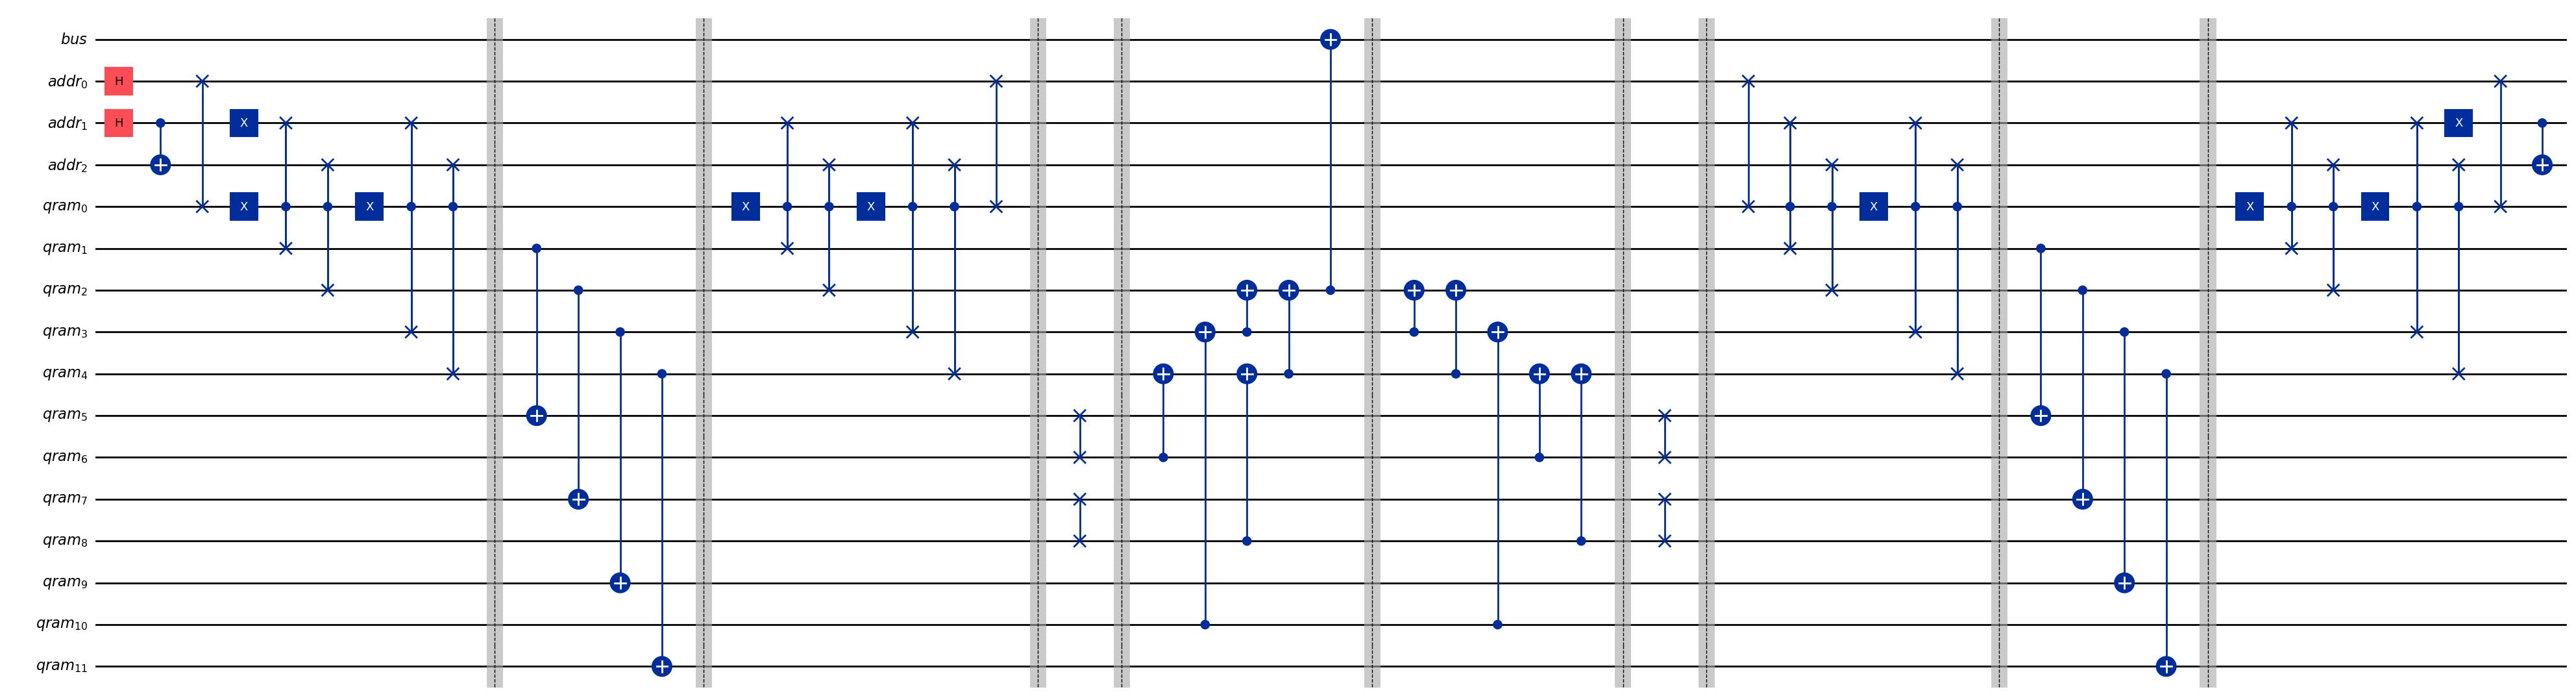

In [4]:
#ADDRESS LOADING

#sovrapposizione degli indirizzi
for i in range (0, m-1):
    qc.h(addr[i])

qc.cx(addr[m-2],addr[m-1]) #ancilla
qc.x(addr[m-2]) 


qc.swap(addr[0],qram[0]) #introduco sovrapposizione negli indirizzi DI MEMORIA (QRAM)

#caricamento degli indirizzi
qc.x(qram[0])

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i])  

qc.x(qram[0]) #flip banco

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i+(m-1)])  #serve per standardizzare 
                                               #l'arrivo all'i-esimo router del secondo banco 
qc.barrier()

for i in range (1, 2*(m-1)+1):        #propaga informazioni alle foglie
    #print(f"i = {i} m+(2*i) = {m + (2*i)}\n")
    qc.cx(qram[i], qram[m+(2*i)])

qc.barrier()

#address recycling

qc.x(qram[0])

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i])  

qc.x(qram[0]) #flip banco

for i in range (1, m):
    #print(f"i = {i} i+(m-1) = {i+(m-1)}\n")
    qc.cswap(qram[0], addr[i], qram[i+(m-1)])

qc.swap(addr[0],qram[0])

qc.barrier()

#DATA RETRIEVAL

for i in range (1, 2+(2**(m-1)//2), 2):
    qc.swap(qram[2*(m-1)+i], qram[(2*(m-1)+i)+1])
qc.barrier()

qc.cx(qram[6],qram[4])
qc.cx(qram[8],qram[4])
qc.cx(qram[10],qram[3])
qc.cx(qram[3],qram[2])
qc.cx(qram[4],qram[2])


qc.cx(qram[2],bus[0])

qc.barrier()

#uncompute
qc.cx(qram[3],qram[2])
qc.cx(qram[4],qram[2])
qc.cx(qram[6],qram[4])
qc.cx(qram[8],qram[4])
qc.cx(qram[10],qram[3])

qc.barrier()

#UNLOAD

for i in range (1, 2+(2**(m-1)//2), 2):
    qc.swap(qram[2*(m-1)+i], qram[(2*(m-1)+i)+1])
qc.barrier()

qc.swap(addr[0],qram[0])

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i])  

qc.x(qram[0]) #flip banco

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i+(m-1)])


qc.barrier()

for i in range (1, 2*(m-1)+1):        
    #print(f"i = {i} m+(2*i) = {m + (2*i)}\n")
    qc.cx(qram[i], qram[m+(2*i)])

qc.barrier()

qc.x(qram[0])

for i in range (1, m):
    qc.cswap(qram[0], addr[i], qram[i])  

qc.x(qram[0]) #flip banco

for i in range (1, m):
    #print(f"i = {i} i+(m-1) = {i+(m-1)}\n")
    qc.cswap(qram[0], addr[i], qram[i+(m-1)])

qc.swap(addr[0],qram[0])
qc.x(addr[m-2])
qc.cx(addr[m-2],addr[m-1]) 

qc.draw('mpl', fold = -1)

In [5]:
from numpy import std


backend_run = GenericBackendV2(qc.num_qubits)
#backend_run = FakePerth()
noise_model = NoiseModel.from_backend(backend_run)
noise_dict = noise_model.to_dict()


# if a probability is supposed to be small, when it's larger than `small_noise_probability`, print a warning message
def shrink_error_probability(error, ratio, verbose=False, small_noise_probability=0.2, zero_threshold=1e-8):
    
    assert isinstance(error, dict)
    snp = small_noise_probability
    zt = zero_threshold
    error_type = error["type"]
    if error_type == "qerror":  # qubit error
        probabilities = error["probabilities"]
        if verbose:
            print("[before]", probabilities)
        # sanity checks, to avoid modifying probabilities in an unexpected way
        if not probabilities[0] > 1-snp:
            print(f"[warning] strange probability[0] < {1-snp}:", probabilities)
        for i in range(1, len(probabilities)):
            if not probabilities[i] < snp:
                print(f"[warning] strange probability[{i}] > {snp}:", probabilities)
        summation = sum(probabilities)
        if not abs(summation - 1) < 1e-8:
            print(f"[warning] strange sum of probability = {summation},", probabilities)
        # modify the probability
        for i in range(1, len(probabilities)):
            probabilities[i] *= ratio
        probabilities[0] = 0
        probabilities[0] = 1 - sum(probabilities)  # normalize
        if verbose:
            print("[ after]", probabilities)
        # then modify instructions, in case the first instruction is not identity
        instructions = error["instructions"]
        first_instruction = instructions[0]
        # the first instruction (with high probability ~= 1) is supposed to be identity under ratio=0; if not then it may still experience error
        for operator in first_instruction:
            name = operator["name"]
            if name == "id":  # identity gate
                pass
            elif name == "kraus":  # a list of Kraus operators, each should be a 2x2 matrix
                params = operator["params"]
                # sanity check
                for kraus in params:
                    assert isinstance(kraus, np.ndarray)
                    assert len(kraus) == 2 and len(kraus[0]) == 2 and len(kraus[1]) == 2
                # check Kraus operator summation
                kraus_sum = np.zeros((2, 2), dtype=complex)
                for kraus in params:
                    kraus_sum += kraus.transpose() @ kraus
                # kraus_sum should be [[1,0],[0,1]]
                if abs(kraus_sum[0,0]-1) > zt or abs(kraus_sum[0,1]) > zt or abs(kraus_sum[1,0]) > zt or abs(kraus_sum[1,1]-1) > zt:
                    print(f"[warning] strange Kraus operators, with summation {kraus_sum}:", params)
                first_kraus = params[0]
                # the first Kraus operator should be [[x,0],[0,x]]
                if abs(first_kraus[0,1]) > zt or abs(first_kraus[1,0]) > zt:
                    print(f"[warning] strange first Kraus operators,", first_kraus)
                # scale all the other Kraus operators
                other_sum = np.zeros((2, 2), dtype=complex)
                for kraus in params[1:]:
                    kraus *= ratio
                    other_sum += kraus.transpose() @ kraus
                if abs(other_sum[0,1]) > zt or abs(other_sum[1,0]) > zt:
                    print(f"[warning] strange first Kraus operators,", first_kraus)
                # update the first Kraus operator
                first_kraus[0,0] = np.sqrt(1 - other_sum[0,0])
                first_kraus[1,1] = np.sqrt(1 - other_sum[1,1])
            else:
                print(f"[warning] unknown operator name: {name}:", operator)
    elif error_type == "roerror":  # read out error
        probabilities = error["probabilities"]
        assert len(probabilities) == 2 and len(probabilities[0]) == 2 and len(probabilities[1]) == 2
        # should be matrix of measurement errors, 2x2 matrix
        if (not probabilities[0][0] > 1-snp) or (not probabilities[0][1] < snp) or (not probabilities[1][0] < snp) or (not probabilities[1][1] > 1-snp):
            print("[warning] strange 2x2 matrix probability", probabilities)
        if not abs(sum(probabilities[0]) - 1) < zt:
            print(f"[warning] strange sum of probabilities[0] = {sum(probabilities[0])},", probabilities[0])
        if not abs(sum(probabilities[1]) - 1) < zt:
            print(f"[warning] strange sum of probabilities[1] = {sum(probabilities[1])},", probabilities[1])
        probabilities[0][1] *= ratio
        probabilities[0][0] = 1 - probabilities[0][1]
        probabilities[1][0] *= ratio
        probabilities[1][1] = 1 - probabilities[1][0]
    else:
        print(f"[warning] unknown error type: {error_type}:", error)

def shrink_probabilities(noise_dict, ratio, verbose=False):
    assert isinstance(noise_dict, dict)
    for key in noise_dict.keys():
        if key == "errors":
            errors = noise_dict["errors"]
            assert isinstance(errors, list)
            for error in errors:
                shrink_error_probability(error, ratio, verbose)
        else:
            print(f"[warning] unknown key in noise dict: {key}")

[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'q

/tmp/ipykernel_27239/3885189998.py:18: DeprecationWarning: from_dict has been deprecated as of qiskit-aer 0.15.0 and will be removed no earlier than 3 months from that release date.
  Reduced_Noise_model=NoiseModel.from_dict(noise_dict)


[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'q

/tmp/ipykernel_27239/3885189998.py:18: DeprecationWarning: from_dict has been deprecated as of qiskit-aer 0.15.0 and will be removed no earlier than 3 months from that release date.
  Reduced_Noise_model=NoiseModel.from_dict(noise_dict)


[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'q

...

/tmp/ipykernel_27239/3885189998.py:18: DeprecationWarning: from_dict has been deprecated as of qiskit-aer 0.15.0 and will be removed no earlier than 3 months from that release date.
  Reduced_Noise_model=NoiseModel.from_dict(noise_dict)


[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'q

/tmp/ipykernel_27239/3885189998.py:18: DeprecationWarning: from_dict has been deprecated as of qiskit-aer 0.15.0 and will be removed no earlier than 3 months from that release date.
  Reduced_Noise_model=NoiseModel.from_dict(noise_dict)


[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'qubits': [0, 1], 'params': ['II']}
[warning] unknown operator name: pauli: {'name': 'pauli', 'q

/tmp/ipykernel_27239/3885189998.py:18: DeprecationWarning: from_dict has been deprecated as of qiskit-aer 0.15.0 and will be removed no earlier than 3 months from that release date.
  Reduced_Noise_model=NoiseModel.from_dict(noise_dict)


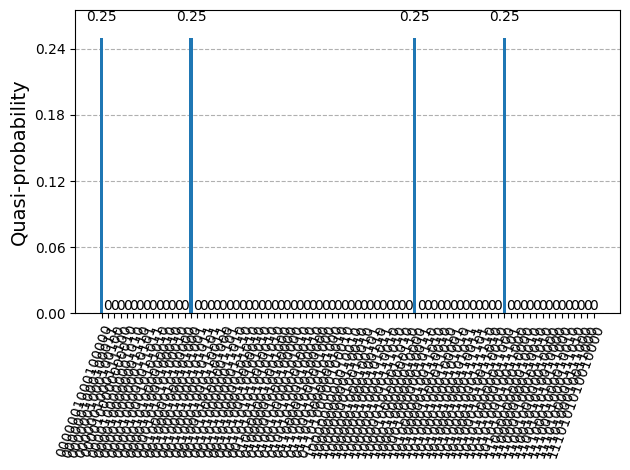

In [6]:
F_bell = []
aver =[]
a  = [1,0.5,0.2,1e-1,0.05,1e-2,1e-3,1e-4]
backend_run = AerSimulator.from_backend(GenericBackendV2(qc.num_qubits))
compiled_circuit = transpile(qc, backend_run)
compiled_circuit.save_statevector()
simulator = AerSimulator()
resulti = simulator.run(compiled_circuit).result()
target_state= resulti.get_statevector(compiled_circuit)
backend_run = GenericBackendV2(qc.num_qubits)
f = open("myfile.txt", "a")
for y in a:
    F_bell = []
    noise_model = NoiseModel.from_backend(backend_run)
    noise_dict = noise_model.to_dict()
    # print(noise_dict)
    shrink_probabilities(noise_dict, y)
    Reduced_Noise_model=NoiseModel.from_dict(noise_dict)
    sim_noise = AerSimulator(noise_model=Reduced_Noise_model)
    job = sim_noise.run(compiled_circuit, shots=2000)   # submit
    result = job.result()            
    rho_fit= result.get_statevector(compiled_circuit)
    F_bell.append(qi.state_fidelity(rho_fit, target_state)) 
    aver.append(np.average(F_bell))

    f.write(f"State Fidelity: F = {aver}")
    f.write(f"Std: S = {std}")
    f.write('\n')
f.close()
plot_histogram(result.get_counts(compiled_circuit))